# **RNN (Recurent Neural Networks)**

[*Recurrence*](https://dictionary.cambridge.org/dictionary/english/recurrence) is the fact of something happening again or an event that keeps repeating.

A [*recurrent neural network*](https://www.ibm.com/think/topics/recurrent-neural-networks) or RNN is a deep [*neural network*](https://www.ibm.com/think/topics/neural-networks) trained on sequential or time series data to create a machine learning (ML) model that can make sequential predictions or conclusions based on sequential inputs.

In simple terms, we may think of RNN as Neural Networks whose inputs are dependent on the the output of the previous iteration. Since the input comes from previous iterations they require time series data or sequential data.

## **Dataset**
As discussed, RNNs are trained on Time-series or sequential data. So lets imagine a sequential dataset as follows:

![Dish variability data image](./Images/dish_weather_state_diagram.png)

A Cafeteria has three items in its menu i.e. Dish A, Dish B and Dish C and the item thats prepared each day depends on the item that was produced yesterday. Futhermore the item to be prepared on each day is affected by the weather of that day i.e. Sunny or Rainy. Lets say that if the current day is sunny, its too hot to go outside so the cafeteria prepares the same dish as the previous day with the remaining ingredients and if its rainy, new ingredients can be bought and the cafeteria can produce a different dish. 

That means that the item to be prepared on a day is dependent on two factors; weather of the said day and the item prepared on the previous day. 

#### **Dataset Model:**
This setup is a classic example of a First-Order [Markov Chain](https://www.geeksforgeeks.org/machine-learning/markov-chain/). A [Markov Chain](https://www.geeksforgeeks.org/machine-learning/markov-chain/) is a way to describe a system that moves between different situations called "states", where the chain assumes the probability of being in a particular state at the next step depends solely on the current state.

In other words, if the future state is dependent only on the present state and no other past states, its called a markov property. In our data model, current day's dish is determined strictly on previous day's dish combined with an external factor i.e. the weather. It's important to note that the addition of weather still requires the previous day's dish and isn't dependent on other states.

### **Generating dataset:**
To create the dataset for this example, we have three rules, listed as follows:

i) There are 3 dishes (A, B, C) and 2 weather conditions (Sunny, Rainy).

ii) If the weather is **Sunny**, the dish stays the same.

iii) If the weather is **Rainy**, the dish advances cyclically: A → B → C → A.

In [26]:
import random
import torch
import torch.nn as nn
import torch.optim as optim

# =====================================================
# 1. Generate dataset
# =====================================================

dishes = ['A', 'B', 'C']
weather_types = ['Sunny', 'Rainy']

dish_to_idx = {d: i for i, d in enumerate(dishes)}
weather_to_idx = {w: i for i, w in enumerate(weather_types)}

def next_dish(dish):
    if dish == 'A':
        return 'B'
    elif dish == 'B':
        return 'C'
    else:
        return 'A'

def generate_sequence(length=1000):
    """
    Returns:
        inputs  = [(dish_t, weather_t), ...]
        targets = [dish_{t+1}, ...]
    """
    current_dish = 'A'

    inputs = []
    targets = []

    for _ in range(length):

        weather = random.choice(weather_types)

        inputs.append((current_dish, weather))

        if weather == 'Sunny':
            new_dish = current_dish
        else:  # Rainy
            new_dish = next_dish(current_dish)

        targets.append(new_dish)

        current_dish = new_dish

    return inputs, targets

##  **Encode Data**
Dish and weather need to be one-hot encoded in order to be used. In total there are three items in the menu and two types of weather in our model. Therefore, in order to encode the three dishes in one-hot encoding we will need three dimensions and as for the weather we need two dimensions.

| Feature | Dimensions |
| :--- | :---: |
| Dish | 3 |
| Weather | 2 |
| **Total Input Vector Size** | **5** |

In [27]:
# =====================================================
# 2. Encode data
# =====================================================

def encode_input(dish, weather):
    """
    One-hot encode dish (3 dims)
    +
    One-hot encode weather (2 dims)

    Total input size = 5
    """
    x = torch.zeros(5)

    x[dish_to_idx[dish]] = 1.0
    x[3 + weather_to_idx[weather]] = 1.0

    return x


inputs, targets = generate_sequence(length=2000)

X = torch.stack([
    encode_input(d, w)
    for d, w in inputs
])

y = torch.tensor([
    dish_to_idx[t]
    for t in targets
])

# RNN expects:
# (batch_size, seq_len, input_size)

X = X.unsqueeze(0)      # (1, seq_len, 5)
y = y.unsqueeze(0)      # (1, seq_len)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([1, 2000, 5])
y shape: torch.Size([1, 2000])


## **RNN Types**

RNNs can be classified into several types based on their development. Each RNN was engineered to address the limitations of the previous:

- **Vanilla RNN:** 
It is the original and simplest form of RNN. At each time step, it computes a hidden state based on the current input and the previous hidden state. It works well for short sequences but struggles with long-term dependencies due to the [vanishing gradient problem](https://www.geeksforgeeks.org/deep-learning/vanishing-and-exploding-gradients-problems-in-deep-learning/).

- **[LSTM (Long Short-Term Memory)](https://www.geeksforgeeks.org/deep-learning/deep-learning-introduction-to-long-short-term-memory/):** 
IT introduces a memory mechanism to overcome the vanishing gradient problem. Each LSTM cell has three gates:

i) Input Gate: Controls how much new information should be added to the cell state.

ii) Forget Gate: Decides what past information should be discarded.

iii) Output Gate: Regulates what information should be output at the current step. This selective memory enables LSTMs to handle long-term dependencies, making them ideal for tasks where earlier context is critical.

- **[GRU (Gated Recurrent Unit)](https://www.geeksforgeeks.org/machine-learning/gated-recurrent-unit-networks/):** 
It is a simplified version of LSTM which contains only two gates i.e Update gate and Reset Gate. You can think of update gate as a combination of input and forget gate from LSTM. This design is simpler and computationally efficient often being able to perform as well as LSTM.

Some other types of RNN:

- **[Bidirectional RNNs](https://www.geeksforgeeks.org/deep-learning/bidirectional-recurrent-neural-network/):**
Bidirectional RNNs process inputs in both forward and backward directions, capturing both past and future context for each time step. This architecture is ideal for tasks where the entire sequence is available, such as named entity recognition and question answering.
</br>

For the given dataset we can use the simple Vanilla RNN because our dataset isn't too complex and doesn't require long term memory and Vanilla RNN can easily find the next dish which only depends on the present dish with no long term range required.

## **Vanilla RNN Model**
Lets create the most basic form of RNN model for our test.

In [28]:
# =====================================================
# 3. Vanilla RNN model
# =====================================================

class DishRNN(nn.Module):
    def __init__(self,
                 input_size=5,
                 hidden_size=3,
                 output_size=3):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True, 
            bias=False, 
            nonlinearity = "tanh"
        )

        self.fc = nn.Linear(hidden_size, output_size, bias=False)

    def forward(self, x):
        # rnn_out:
        # (batch, seq_len, hidden_size)

        rnn_out, hidden = self.rnn(x)

        logits = self.fc(rnn_out)

        return logits


model = DishRNN()

Printing the model shows our RNN(5, 3) layer which means 5 input vector and 3 hidden layers. This is followed by a Linear(3, 3) layer which shows that our output has three dimensions. Both of them show that the bias is false.

In [29]:
model

DishRNN(
  (rnn): RNN(5, 3, bias=False, batch_first=True)
  (fc): Linear(in_features=3, out_features=3, bias=False)
)

## **Training Setup**
It consists of two parts:

- **Loss:** CrossEntropyLoss, suitable for multi-class classification (predicting one of 3 dishes at each timestep).
- **Optimizer:** Adam with learning rate 0.01.

In [30]:
# =====================================================
# 4. Training setup
# =====================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

## **Training Loop**

For each epoch we follow these three steps:
1. Forward pass 
2. Reshape logits 
3. Backpropagate and update weights.

Loss is printed every 50 epochs to track convergence.

In [31]:
# =====================================================
# 5. Training loop
# =====================================================



epochs = 300
losses = []

print("Training loop:")

for epoch in range(epochs):

    optimizer.zero_grad()

    logits = model(X)

    #recording loss 
    loss = criterion(logits.view(-1, 3), y.view(-1)) #reshaping loss 
    loss.backward()

    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss = {loss.item():.6f}")

Epochs and Loss
Epoch [50/300] Loss = 0.837169
Epoch [100/300] Loss = 0.480007
Epoch [150/300] Loss = 0.348227
Epoch [200/300] Loss = 0.300086
Epoch [250/300] Loss = 0.275649
Epoch [300/300] Loss = 0.240723


This data shows that with each new epoch loss is being minimized. We can see it in a graph.

## **Visualization of loss**

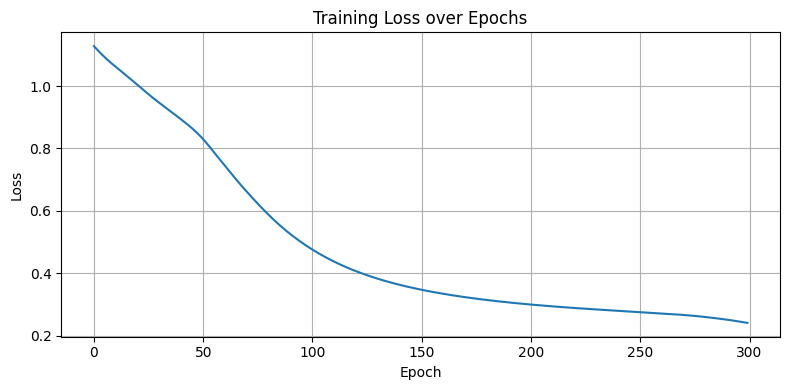

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

The graph shows the minimization of loss with each 50 epochs. The final loss comes to 0.028435 based on the output from the training loop.

## Evaluation

In [33]:
# =====================================================
# 6. Evaluation
# =====================================================

with torch.no_grad():

    logits = model(X)

    preds = logits.argmax(dim=-1)

    accuracy = (
        (preds == y).float().mean().item()
    )

print("\nAccuracy:", accuracy)


Accuracy: 1.0


Accuracy of 1.0 shows that the model is perfectly trained for the dataset. We can visualize the accuracy using a confusion matrix.

### **Output Confusion Matrix**

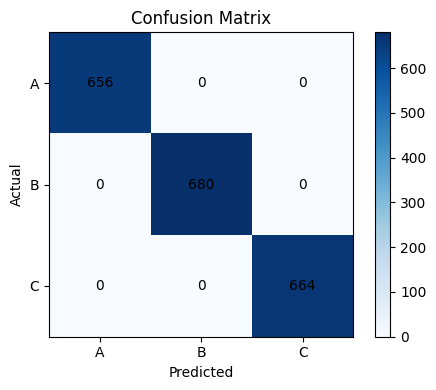

In [34]:
import matplotlib.pyplot as plt
import numpy as np
with torch.no_grad():
    logits = model(X)
    preds = logits.argmax(dim=-1).squeeze().numpy()

y_true = y.squeeze().numpy()

cm = np.zeros((3, 3), dtype=int)
for t, p in zip(y_true, preds):
    cm[t][p] += 1

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0,1,2], ['A','B','C'])
plt.yticks([0,1,2], ['A','B','C'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i][j], ha='center', va='center')
plt.tight_layout()
plt.show()

The output confusion matrix confirms 100% accuracy for all three dish predictions. There was no missclassification of any dishes which is represented by the 0s in the matrix here. Furthermore, we can note that the dataset is roughly balanced between 656 for dish A, 680 for dish B and 664 for dish C 

## Test on All Possible Transitions

Instead of testing on the training sequence, we need to test the model on each of the 6 possible combinations of dish and weather.

In [35]:
# =====================================================
# 7. Test on all possible transitions
# =====================================================

print("\nLearned transitions:\n")

test_cases = [
    ('A', 'Sunny'),
    ('A', 'Rainy'),
    ('B', 'Sunny'),
    ('B', 'Rainy'),
    ('C', 'Sunny'),
    ('C', 'Rainy'),
]

hidden = None

for dish, weather in test_cases:

    x = encode_input(dish, weather)
    x = x.unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(-1).item()

    print(
        f"Current Dish={dish:1s}, "
        f"Weather={weather:5s} "
        f"--> Predicted Next Dish={dishes[pred]}"
    )


Learned transitions:

Current Dish=A, Weather=Sunny --> Predicted Next Dish=A
Current Dish=A, Weather=Rainy --> Predicted Next Dish=B
Current Dish=B, Weather=Sunny --> Predicted Next Dish=B
Current Dish=B, Weather=Rainy --> Predicted Next Dish=C
Current Dish=C, Weather=Sunny --> Predicted Next Dish=C
Current Dish=C, Weather=Rainy --> Predicted Next Dish=A


Let's check the weights: 

In [36]:
for name, param in model.named_parameters():
    print(name)
    print(param.data)
    print()

rnn.weight_ih_l0
tensor([[-2.6751, -0.4152,  2.1038, -1.9059,  1.0130],
        [ 1.4670, -0.5697, -2.1179,  0.2688, -2.5285],
        [ 1.2447, -0.8387,  2.1821,  2.1057, -0.0390]])

rnn.weight_hh_l0
tensor([[-0.5366, -0.5174, -0.1676],
        [ 0.8251,  1.4361,  0.3606],
        [ 1.3286, -0.3028,  0.1289]])

fc.weight
tensor([[ 2.8276,  2.6534,  1.9711],
        [-1.8139, -1.2516, -1.6198],
        [ 1.8809, -1.2894, -1.4442]])



## **Discussion:**
RNN are Neural Networks whose inputs are dependent on the the output of the previous iteration. Since the input comes from previous iterations they require time series data or sequential data.

Types:

1) Vanilla
2) LSTM
3) GRU


#### **What is hidden size?**
The hidden_size is the dimensionality of the RNN's hidden state vector h_t. It's generally used as memory at each timestep.

h_t = tanh(W_ih · x_t + W_hh · h_(t-1))

The hidden_size determines how many hidden units exist in the model. The shape of hidden size is automatically set to weight_ih (hidden_size × input_size) and weight_hh (hidden_size × hidden_size).

Hidden size controls the model's capacity to encode and carry forward information about past inputs. Hidden size for a model needs to be chosen appropriately to properly balance the model. A larger hidden size means that it can hold more information and therefore more complex patterns. When hidden size is too large, it adds extra parameters and we risk overfitting. However, when the hidden size is too small it won't be able to store the necessary information and lead to underfitting.

For our model, hidden_size was 3 to match the dimenstion of dish classes. Since there are only three dishes to choose from 3 hidden units are enough to let the network represent each dish uniquely. Hence the model reaches 100% accuracy.


## **Conclusion**

The appropriate dataset constituting 3 dishes and 2 weather patterns was produced. The vanilla RNN model was implemented and the model successfully learned the transition rule for the dataset, achieving 100% accuracy on all 6 possible transitions. 

We could properly train the model using the hidden size of 3 because the dishes could be represented using 3 dimensions and since this dataset only needed the present state to predict the future state and didn't require any other past states, simple vanilla model could achieve a 100% accuracy.

This concludes that the correct hidden size should be chosen alongside an appropriate model to achieve high accuracy. 